# Bayesian Inference for Systems of Elementary Reactions

This notebook runs Bayesian parameter inference on an enzyme kinetics ODE model and generates diagnostic plots. It is **Step 2 of 2** — run `guided_solver_config_builder.ipynb` first to generate the required `solver_params.json` configuration file.

---
*Annette Thompson · Fox and Shirts Labs, CU Boulder · 2026 · Developed with assistance from GitHub Copilot (Claude Sonnet 4.6)*

## Import Libraries

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "../Utilities")

from pathlib import Path
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import preliz as pz

from effective_parameter_limits import evaluate_effective_parameter_limits
from experiment_framework import load_experiment_bundle
from inference_runner import (
    _fit_prior,
    get_free_parameter_names,
    import_solver_params,
    run_bayesian_inference,
    summarize_inference_metrics,
 )
from inference_plotting import (
    plot_diffusion_feasible_parameter_family,
    plot_diffusion_feasible_parameter_marginals,
    plot_inference_diagnostics,
)
from reaction_model_builder import build_ode_system_from_reactions

Total JAX local devices initialized: 1
[CpuDevice(id=0)]


/Users/annettethompson/anaconda3/envs/Bayesian/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Configure and Run

Set the key variables below, then run this cell.

| Variable | Value | Effect |
|---|---|---|
| `use_existing_results` | `False` | **Run full inference** — samples prior then posterior (~10–30 min depending on hardware) |
| `use_existing_results` | `True` | **Load saved results** — skips sampling and goes straight to plotting (requires a previous run) |
| `folder_name` | `"FabD kon inference"` | Folder used to find the solver JSON and organize reactions, data, calculation files, and results |

> **Paths:** The solver params JSON sets `path_base` to the Python Model home directory. Reaction, data, calculation-module, and output paths are stored relative to that home directory.

In [ ]:
folder_name = "Chain Scaling Tests/Chain C4_NoFB - a1_0.1-10_no_floor"

# Toggle workflow mode:
use_existing_results = False
use_log_param_axis = True

# Plot styling
plt.style.use("default")

solver_params_file = f"solver_params.json"
solver_param_path = Path(f"../Results/{folder_name}/{solver_params_file}")
imported_solver_params = import_solver_params(solver_param_path)
solver_params = imported_solver_params.solver_params
output_paths = imported_solver_params.output_paths

def print_section(title):
    print(f"\n=== {title} ===")

def print_item(label, value):
    print(f"- {label}: {value}")

if "trace_plot_file" not in output_paths:
    raise KeyError("Missing output_paths key: trace_plot_file")

reactions_source = imported_solver_params.reactions_source
results_save_dir = imported_solver_params.results_save_dir
prior_samples_file = imported_solver_params.prior_samples_file
posterior_samples_file = imported_solver_params.posterior_samples_file
trace_plot_file = output_paths["trace_plot_file"]

# Ensure output directory exists before writing any results
results_save_dir.mkdir(parents=True, exist_ok=True)

prior_file_path = results_save_dir / prior_samples_file
posterior_file_path = results_save_dir / posterior_samples_file
trace_path = results_save_dir / trace_plot_file

if not use_existing_results:
    result = run_bayesian_inference(solver_param_path)

    inference_data = result.posterior
    experiment_for_plots = result.experiment
    free_params = result.free_params
    summary_table = result.summary
    loo_result = result.loo

    experiment_summary_text = result.experiment_summary
    prior_path_text = result.prior_file
    results_path_text = result.results_file
    trace_path_text = str(trace_path)
else:
    if not posterior_file_path.exists():
        raise FileNotFoundError(
            f"Posterior samples file not found: {posterior_file_path}. Set use_existing_results=False to run inference first."
        )

    inference_data = az.from_netcdf(posterior_file_path)

    _, species_names_for_experiment, _, _, _ = build_ode_system_from_reactions(
        reactions_source, scaling_group=solver_params["scaling_groups"])
    experiment_for_plots = load_experiment_bundle(
        solver_params=solver_params,
        solver_params_file=str(solver_param_path),
        species_names=species_names_for_experiment,
    )

    free_params = get_free_parameter_names(solver_params)
    metrics = summarize_inference_metrics(inference_data, free_params)
    free_params = metrics["free_params"]
    summary_table = metrics["summary"]
    loo_result = metrics["loo"]

    experiment_summary_text = "Loaded existing posterior samples (inference run skipped)."
    prior_path_text = str(prior_file_path) if prior_file_path.exists() else "Not found"
    results_path_text = str(posterior_file_path)
    trace_path_text = str(trace_path)

print_section("Run Status")
print(experiment_summary_text)

print_section("Files")
print_item("Prior samples", prior_path_text)
print_item("Posterior samples", results_path_text)

print_section("Posterior Summary")
display(summary_table)

print_section("Model Comparison")
print("LOO")
print(loo_result)

diagnostic_artifacts = plot_inference_diagnostics(
    inf_data=inference_data,
    free_params=free_params,
    experiment=experiment_for_plots,
    save_path=trace_path_text,
    include_tuning_in_trace=True,
    posterior_start_line=True,
    show=True,
    use_log_param_axis=use_log_param_axis,
 )
trace_artifacts = diagnostic_artifacts["trace_diagnostics"]
parameter_marginal_artifacts = diagnostic_artifacts["parameter_marginals"]
prior_marginal_artifacts = diagnostic_artifacts["prior_marginals"]
predictive_artifacts = diagnostic_artifacts["predictive"]

print_section("Saved Plots")
if trace_artifacts.get("plot_file"):
    print_item("Trace diagnostics", trace_artifacts["plot_file"])
if parameter_marginal_artifacts.get("plot_file"):
    print_item("Posterior marginals", parameter_marginal_artifacts["plot_file"])
if prior_marginal_artifacts.get("plot_file"):
    print_item("Prior marginals", prior_marginal_artifacts["plot_file"])
elif not prior_marginal_artifacts.get("prior_var_names"):
    print("- Prior marginals: no matching prior variables found")

if predictive_artifacts.get("data_vs_results_plot_files"):
    print_item("Predictive plot count", len(predictive_artifacts["data_vs_results_plot_files"]))
    for dataset_name, plot_path in predictive_artifacts["data_vs_results_plot_files"].items():
        print_item(dataset_name, plot_path)

plot_artifacts = {
    "trace_diagnostics": trace_artifacts,
    "parameter_marginals": parameter_marginal_artifacts,
    "prior_marginals": prior_marginal_artifacts,
    "predictive": predictive_artifacts,
}


=== Run Configuration ===
- Solver params file: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Results/Chain Scaling Tests/Chain C4 - a2/solver_params.json
- Path base: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model
- Reactions source: [Path('/Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Reactions/EC_FAS_ME1/C4/FabD.yaml'), Path('/Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Reactions/EC_FAS_ME1/C4/FabH.yaml'), Path('/Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox

---
## Step 3: Diffusion-Limited Effective Parameter Diagnostics

Define effective-parameter limit rules, then evaluate them against the posterior samples already in `inference_data`.

This step is independent of sampling: after changing the limits or patterns below, rerun this cell only. It works with both fresh inference results and `use_existing_results=True`.


=== Diffusion Feasibility ===
- Feasible posterior draws: 800/800 (100.0%)

=== Limited Effective-Parameter Summary ===


,rule_name,rxn_name,direction,param_name,reactants,scale_expr,scale_param_names,lower,upper,n_draws,n_violations,violation_fraction,min_effective,median_effective,max_effective
2,protein_protein_diffusion_limit,C2_FabH_Act_binding_MalACP,fwd,kon_H_Act_MalACP,C2_FabH_Act + C3_MalACP,NaN,,-inf,629.0,800,0,0.0,618.335961,618.335961,618.335961
0,protein_ligand_diffusion_limit,FabD_binding_MalCoA,fwd,kon_D_MalCoA,FabD + C3_MalCoA,NaN,,-inf,1650.0,800,0,0.0,189.964965,189.964965,189.964965
1,protein_protein_diffusion_limit,FabD_Act_binding_ACP,fwd,kon_D_Act_ACP,C3_FabD_Act + ACP,NaN,,-inf,629.0,800,0,0.0,77.291995,77.291995,77.291995
18,protein_ligand_diffusion_limit,FabG_binding_NADPH,fwd,kon_G_NADPH,FabG + NADPH,NaN,,-inf,1650.0,800,0,0.0,60.249578,60.249578,60.249578
19,protein_protein_diffusion_limit,C4_FabG_binding_BKeAcACP,fwd,kon_G_BKeAcACP,FabG_NADPH + C4_BKeAcACP,NaN,,-inf,629.0,800,0,0.0,9.698211,9.698211,9.698211
20,protein_protein_diffusion_limit,C6_FabG_binding_BKeAcACP,fwd,kon_G_BKeAcACP,FabG_NADPH + C6_BKeAcACP,NaN,,-inf,629.0,800,0,0.0,9.698211,9.698211,9.698211
21,protein_protein_diffusion_limit,C8_FabG_binding_BKeAcACP,fwd,kon_G_BKeAcACP,FabG_NADPH + C8_BKeAcACP,NaN,,-inf,629.0,800,0,0.0,9.698211,9.698211,9.698211
22,protein_protein_diffusion_limit,C10_FabG_binding_BKeAcACP,fwd,kon_G_BKeAcACP,FabG_NADPH + C10_BKeAcACP,NaN,,-inf,629.0,800,0,0.0,9.698211,9.698211,9.698211
23,protein_protein_diffusion_limit,C12_FabG_binding_BKeAcACP,fwd,kon_G_BKeAcACP,FabG_NADPH + C12_BKeAcACP,NaN,,-inf,629.0,800,0,0.0,9.698211,9.698211,9.698211
24,protein_protein_diffusion_limit,C14_FabG_binding_BKeAcACP,fwd,kon_G_BKeAcACP,FabG_NADPH + C14_BKeAcACP,NaN,,-inf,629.0,800,0,0.0,9.698211,9.698211,9.698211



=== Posterior Draw Feasibility Summary ===


,draw_index,is_feasible,n_violations,max_violation_ratio,worst_channel,worst_rule
0,0,True,0,0.0,None,None
1,1,True,0,0.0,None,None
2,2,True,0,0.0,None,None
3,3,True,0,0.0,None,None
4,4,True,0,0.0,None,None
5,5,True,0,0.0,None,None
6,6,True,0,0.0,None,None
7,7,True,0,0.0,None,None
8,8,True,0,0.0,None,None
9,9,True,0,0.0,None,None



=== Saved Diffusion Diagnostic Plots ===
- Feasible area marginals: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Results/Test FabD FabH FabG - a1 a2 c1/trace_plot_diffusion_feasible_marginals.pdf
- Feasible parameter family: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Results/Test FabD FabH FabG - a1 a2 c1/trace_plot_diffusion_feasible_family.pdf


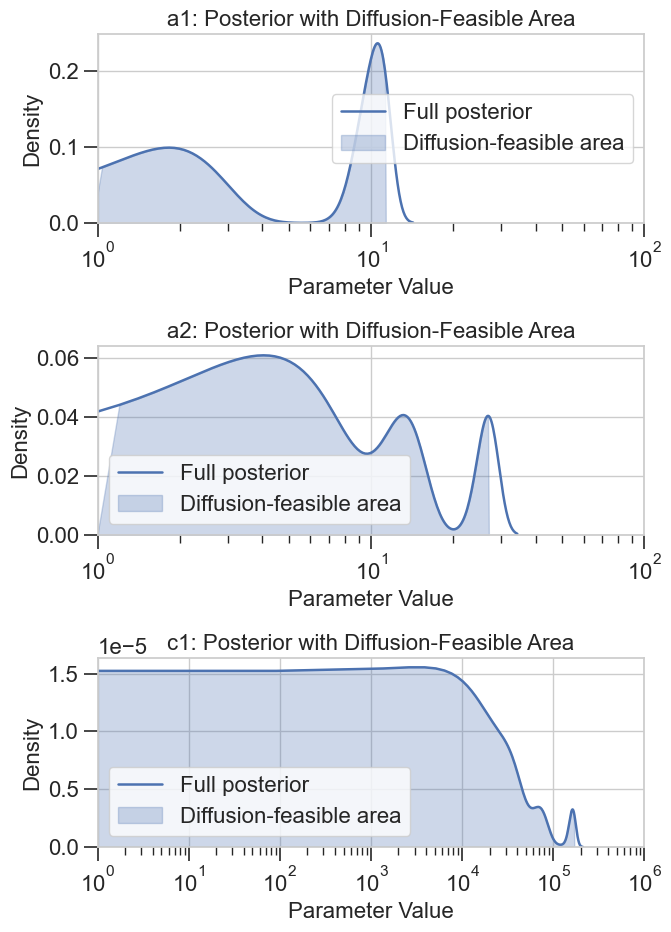

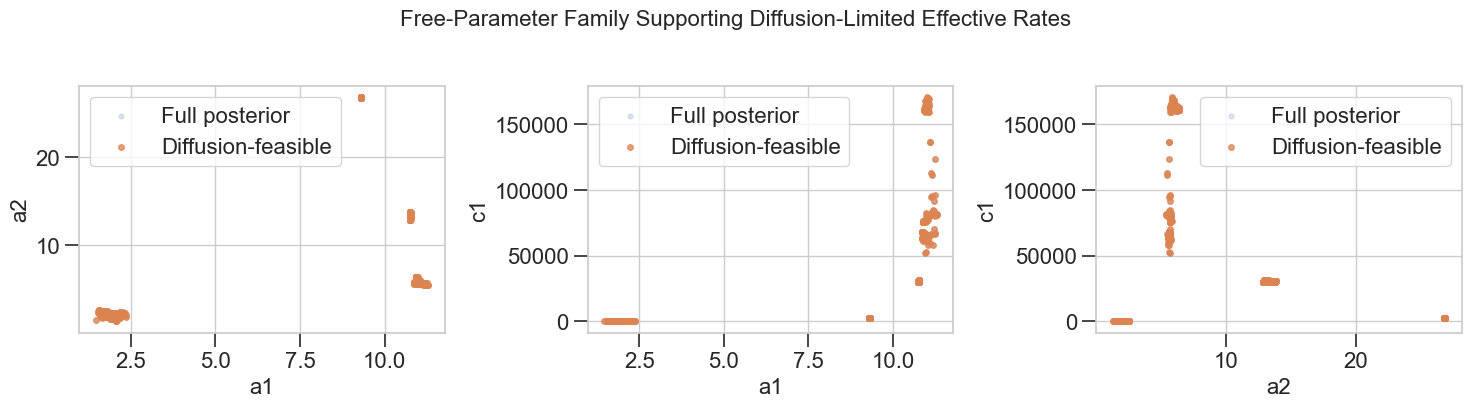

In [24]:
# Edit these rules and rerun this cell to recompute diffusion-limit feasibility.
# Rules are applied to final effective values after scaling: base_parameter * scaling_expression(theta).

protein_pattern = r"Fab[A-Z]|TesA|ACP"
kon_name_pattern = r"(^kon|_k_on_)"

effective_parameter_limits = [
    {
        "name": "protein_protein_diffusion_limit",
        "param_name_pattern": kon_name_pattern,
        "reactant_name_patterns": [protein_pattern],
        "reactant_match_count": 2,
        "upper": 629.0,
    },
    {
        "name": "protein_ligand_diffusion_limit",
        "param_name_pattern": kon_name_pattern,
        "reactant_name_patterns": [protein_pattern],
        "reactant_match_count": 1,
        "upper": 1650.0,
    },
    # Exact base-parameter example:
    # {"name": "specific_param_limit", "param_names": ["some_k_on_param"], "lower": 0.0, "upper": 1650.0},
    # Exact scaling-parameter example: checks effective values for every channel whose scale expression uses a1.
    # {"name": "a1_scaled_effective_limit", "param_names": ["a1"], "upper": 1650.0},
    # Scaling-parameter pattern example:
    # {"name": "a_family_scaled_effective_limit", "scaling_param_name_pattern": "^a", "upper": 1650.0},
]

diffusion_limit_result = evaluate_effective_parameter_limits(
    inf_data=inference_data,
    reactions_source=reactions_source,
    free_params=free_params,
    effective_parameter_limits=effective_parameter_limits,
)
diffusion_feasibility_mask = diffusion_limit_result.feasibility_mask

feasible_count = int(np.sum(diffusion_feasibility_mask))
total_count = int(diffusion_feasibility_mask.size)
print_section("Diffusion Feasibility")
print_item("Feasible posterior draws", f"{feasible_count}/{total_count} ({feasible_count / total_count:.1%})")

if diffusion_limit_result.channel_summary.empty:
    print("- Limited effective-parameter summary: no matching reaction channels")
else:
    print_section("Limited Effective-Parameter Summary")
    display(
        diffusion_limit_result.channel_summary.sort_values(
            ["violation_fraction", "max_effective"],
            ascending=[False, False],
        )
    )

print_section("Posterior Draw Feasibility Summary")
display(diffusion_limit_result.draw_summary.head(20))

diffusion_marginal_path = trace_path.with_name(f"{trace_path.stem}_diffusion_feasible_marginals.pdf")
diffusion_family_path = trace_path.with_name(f"{trace_path.stem}_diffusion_feasible_family.pdf")

diffusion_marginal_artifacts = plot_diffusion_feasible_parameter_marginals(
    inf_data=inference_data,
    free_params=free_params,
    feasibility_mask=diffusion_feasibility_mask,
    save_file=str(diffusion_marginal_path),
    show=True,
    use_log_param_axis=use_log_param_axis,
)
diffusion_family_artifacts = plot_diffusion_feasible_parameter_family(
    inf_data=inference_data,
    free_params=free_params,
    feasibility_mask=diffusion_feasibility_mask,
    save_file=str(diffusion_family_path),
    show=True,
)

plot_artifacts["diffusion_feasible_marginals"] = diffusion_marginal_artifacts
plot_artifacts["diffusion_feasible_family"] = diffusion_family_artifacts

print_section("Saved Diffusion Diagnostic Plots")
if diffusion_marginal_artifacts.get("plot_file"):
    print_item("Feasible area marginals", diffusion_marginal_artifacts["plot_file"])
if diffusion_family_artifacts.get("plot_file"):
    print_item("Feasible parameter family", diffusion_family_artifacts["plot_file"])

---
## Step 4: Visualize Prior Distributions

The next cells plot the **prior distributions** for each free parameter — these represent your beliefs about plausible parameter values *before* seeing the data. Compare these to the posterior marginals generated above to see how much the data updated your beliefs.

Each prior is shaped by the `lower`/`upper` bounds and mass % (default 95%) you set in the config builder. The distribution is chosen automatically via maximum entropy (`preliz.maxent`).

Bounds are read directly from `solver_params` so these plots always stay in sync with your config.

/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_82456/3599245655.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=18)


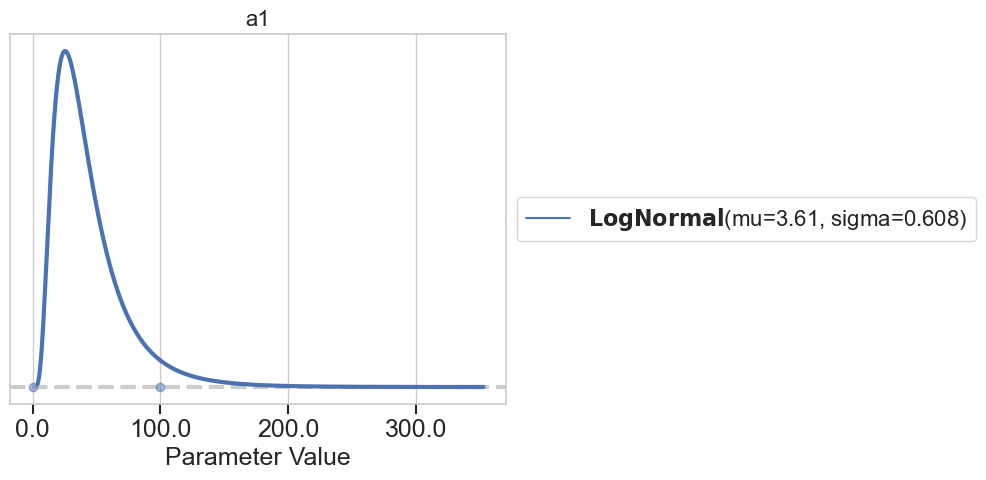

/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_82456/3599245655.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=18)


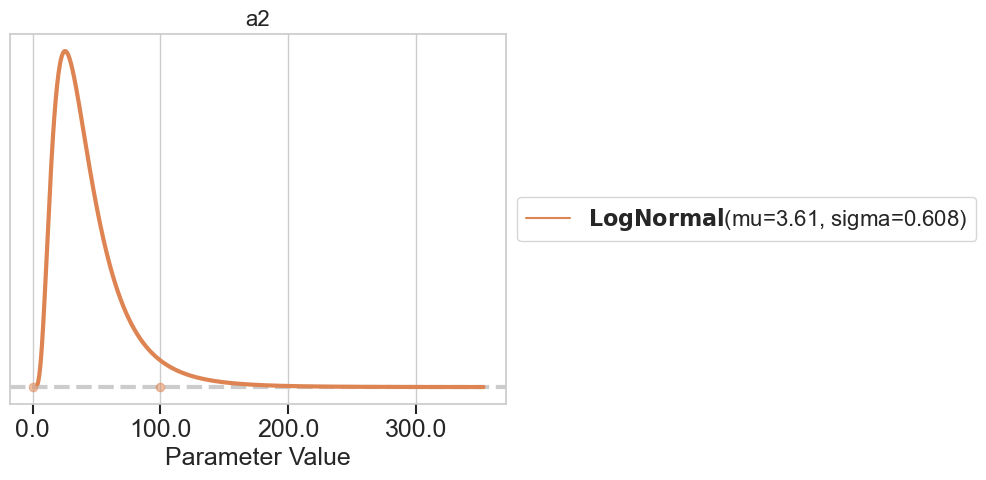

/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_82456/3599245655.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=18)


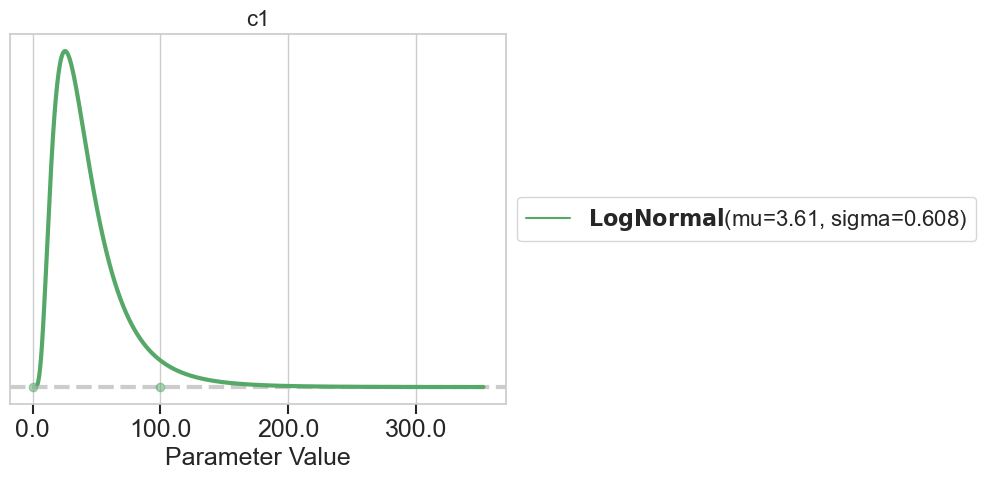

In [25]:
colors = ["C0", "C1", "C2", "C3", "C4"]

for i, param_spec in enumerate(solver_params["free_kinetic_params"]):
    # The prior the sampler actually uses, including a fixed median if the config sets one.
    result = _fit_prior(param_spec["param_name"], param_spec["prior_dist_params"])
    result.plot_pdf(color=colors[i % len(colors)])
    ax = plt.gca()
    for line in ax.lines:
        line.set_linewidth(3)
    ax.tick_params(width=1.5, length=7)
    ax.set_xlabel("Parameter Value", fontsize=18)
    ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=18)
    ax.set_title(param_spec["param_name"], fontsize=16)
    plt.show()